# 4. Limpieza y transformación inicial

### 4.1 Objetivo de esta fase

Queremos que las columnas tengan tipos y significados consistentes.

Los principales problemas detectados fueron:

- TotalCharges está como object.
- BeginDate está como texto.
- EndDate mezcla fechas y "No".
- Los NaN generados por el merge de Internet y telefonía tienen significado estructural.
- SeniorCitizen está almacenada como entero, aunque semánticamente es binaria/categórica.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones de visualización para que las gráficas se vean impecables
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Cargamos el archivo generado por el Cuaderno 1
data = pd.read_csv('../data/interconnect_raw.csv')
print(f"Dataset crudo unificado cargado con éxito. Filas: {data.shape[0]}, Columnas: {data.shape[1]}")


Dataset crudo unificado cargado con éxito. Filas: 7043, Columnas: 20


### 4.2. TotalCharges

**¿Por qué TotalCharges es object si representa dinero?**

In [3]:
data["TotalCharges"].dtype

dtype('O')

In [4]:
data["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

Si parecen números, ¿qué impide que pandas los trate como números?

Existen 11 cadenas vacías.

### 4.3 Identificar los valores problemáticos

In [5]:
blank_total_charges = (
    data["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
)

blank_total_charges.sum()

np.int64(11)

In [6]:
# Ahora los observamos:

data.loc[
    blank_total_charges,
    [
        "customerID",
        "BeginDate",
        "EndDate",
        "MonthlyCharges",
        "TotalCharges"
    ]
]

,customerID,BeginDate,EndDate,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,52.55,
753,3115-CZMZD,2020-02-01,No,20.25,
936,5709-LVOEQ,2020-02-01,No,80.85,
1082,4367-NUYAO,2020-02-01,No,25.75,
1340,1371-DWPAZ,2020-02-01,No,56.05,
3331,7644-OMVMY,2020-02-01,No,19.85,
3826,3213-VVOLG,2020-02-01,No,25.35,
4380,2520-SGTTA,2020-02-01,No,20.00,
5218,2923-ARZLG,2020-02-01,No,19.70,
6670,4075-WKNIU,2020-02-01,No,73.35,


La observación relevante es:

- BeginDate = 2020-02-01
- EndDate = No

### 4.4 ¿Qué significado tienen esos 11 casos?

La documentación señala que los datos contractuales son válidos al 1 de febrero de 2020.

Y esos clientes comenzaron precisamente: 2020-02-01

**Hipótesis:** 

Son clientes recién incorporados en la fecha de corte y todavía no han acumulado cargos históricos.

### 4.5 ¿Qué opciones tenemos?

**Opción A — Eliminar los 11 clientes**

Problema:

estaríamos eliminando clientes válidos simplemente porque su historial es reciente.

Además:

11/7043≈0.16%

Es poco, pero sigue siendo pérdida innecesaria.

**Opción B — Imputar la mediana**

Pero todavía ni siquiera podríamos calcularla correctamente sin convertir antes la columna.

La mediana representa el gasto acumulado típico de toda la cartera. Un cliente que acaba de ingresar no debería recibir artificialmente el gasto histórico de un cliente promedio. Eso introduciría información falsa.

**Opción C — Interpretar TotalCharges = 0**

* SI: fecha de inicio = fecha de corte
* Su antigüedad acumulada es prácticamente cero.

Entonces conceptualmente: TotalCharges ≈ 0

Es razonable. No significa que su servicio sea gratuito. Significa que todavía no existe un historial acumulado de facturación.

### 4.6 Transformación de TotalCharges

In [7]:
# Primero convertimos los espacios en NaN

data["TotalCharges"] = (
    data["TotalCharges"]
    .replace(r"^\s*$", np.nan, regex=True)
)

data["TotalCharges"].isna().sum()

np.int64(11)

In [8]:
# convertimos
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# comprobamos

data["TotalCharges"].dtype

dtype('float64')

### 4.7 Imputar únicamente estos casos

In [9]:
data["TotalCharges"] = data["TotalCharges"].fillna(0)
# Validamos
data["TotalCharges"].isna().sum()

np.int64(0)

In [10]:
data["TotalCharges"].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

Ahora pandas podrá tratarla como variable numérica.

### Conclusión. 

Los valores vacíos de TotalCharges no fueron imputados mediante una medida estadística general. Se observó que corresponden exclusivamente a clientes cuya fecha de alta coincide con la fecha de referencia del dataset. Por ello se interpretaron como clientes sin cargos acumulados y se asignó un valor de 0.

### 4.9 Convertir BeginDate

¿Qué tipo de variable es BeginDate?

Actualmente:

In [11]:
data["BeginDate"].dtype

dtype('O')

Conceptualmente es una fecha.

Entonces:

In [12]:
data["BeginDate"] = pd.to_datetime(
    data["BeginDate"],
    errors="raise" # errors="raise" Porque queremos saber si existe alguna fecha inválida.
)

### 4.10 Validar BeginDate

In [13]:
data["BeginDate"].dtype

dtype('<M8[ns]')

In [14]:
data["BeginDate"].min(), data["BeginDate"].max()

(Timestamp('2013-10-01 00:00:00'), Timestamp('2020-02-01 00:00:00'))

### 4.11 EndDate requiere más cuidado

Aquí no podemos hacer todavía: 
 
pd.to_datetime(data["EndDate"])

porque contiene: "No" y No no es una fecha.

Posteriormente se utilizara esta variable para construir formalmente el target.

Una práctica limpia sería conservar: EndDate y crear una versión temporal auxiliar.

### 4.12 Crear EndDateParsed

In [15]:
data["EndDateParsed"] = pd.to_datetime(
    data["EndDate"].replace("No", pd.NA),
    errors="coerce"
)

Ahora tenemos: EndDate como información original, y: EndDateParsed como representación temporal.

Clientes activos:

- EndDate = "No"
- EndDateParsed = NaT

Clientes que terminaron:

- EndDate = "2019-12-01"
- EndDateParsed = 2019-12-01

### 4.13 ¿Por qué conservar ambas?

Porque todavía estamos en limpieza.

En el punto 5 podremos decir: EndDate → fuente para crear Churn y después decidir qué columnas conservar para modelado.

No se quiere modificar una variable crítica antes de definir formalmente el target.

### 4.14 Validar EndDate

In [16]:
# comprobar

data[["EndDate", "EndDateParsed"]].head(10)

,EndDate,EndDateParsed
0,No,NaT
1,No,NaT
2,2019-12-01 00:00:00,2019-12-01
3,No,NaT
4,2019-11-01 00:00:00,2019-11-01
5,2019-11-01 00:00:00,2019-11-01
6,No,NaT
7,No,NaT
8,2019-11-01 00:00:00,2019-11-01
9,No,NaT


In [17]:
data["EndDateParsed"].isna().sum()

np.int64(5174)

In [18]:
# Eso debería coincidir con los clientes cuyo: EndDate == "No"

(data["EndDate"] == "No").sum()

np.int64(5174)

In [19]:
# convertirlo en una regla

assert (
    data["EndDateParsed"].isna().sum()
    ==
    (data["EndDate"] == "No").sum()
)

print("EndDate transformada correctamente.")

EndDate transformada correctamente.


### 4.15 Tratar ausencia de Internet

Después de realizar el `LEFT JOIN`, se identificaron **1,526 clientes** con:

```text
InternetService = NaN
```

Además, estos clientes también presentan valores `NaN` en todas las variables relacionadas con los servicios de internet, como:

- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`

## Interpretación del valor ausente

En este caso, es necesario determinar si el valor `NaN` representa:

- Un dato desconocido o no registrado.
- La ausencia del servicio de internet.

Al observar el patrón completo de valores ausentes y la estructura de las tablas, se plantea la siguiente hipótesis:

> **La ausencia de un registro en la tabla `internet` representa la ausencia del servicio de internet.**

La documentación indica que los archivos provienen de distintas fuentes de servicios y que el servicio de internet es uno de los principales productos ofrecidos por Interconnect.

Por lo tanto, los valores ausentes no se interpretarán simplemente como datos desconocidos. Se representarán explícitamente mediante categorías que indiquen la ausencia del servicio.

## Tratamiento propuesto

La columna `InternetService` podrá completarse de la siguiente manera:

```text
NaN → No internet service
```

De forma similar, las variables relacionadas con servicios adicionales de internet podrán transformarse utilizando la misma categoría:

```text
NaN → No internet service
```

De esta manera, el modelo podrá distinguir entre:

- Clientes con servicio DSL.
- Clientes con servicio de fibra óptica.
- Clientes sin servicio de internet.

Este tratamiento permite conservar el significado empresarial de los datos y evita perder información durante la preparación del dataset.

### 4.16 Crear una categoría de ausencia de Internet

In [20]:
# Comprobamos

data["InternetService"].isna().sum()

np.int64(1526)

In [21]:
internet_columns = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# rellenamos

data[internet_columns] = (
    data[internet_columns]
    .fillna("No internet service")
)

data[internet_columns].isna().sum()

InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

## 4.17 ¿Por qué no utilizar `"No"`?

Podríamos completar los valores ausentes utilizando la categoría:

```text
No
```

Sin embargo, este tratamiento provocaría una pérdida de información empresarial importante.

## Diferencia entre las situaciones

Por ejemplo, el valor:

```text
OnlineSecurity = No
```

podría significar que:

> El cliente tiene contratado el servicio de internet, pero no contrató el servicio adicional de seguridad en línea.

En cambio, el valor:

```text
OnlineSecurity = No internet service
```

significa que:

> El cliente no tiene contratado el servicio de internet y, por lo tanto, tampoco puede tener el servicio de seguridad en línea.

Estas son dos situaciones comerciales distintas:

| Valor | Interpretación |
|---|---|
| `No` | El cliente tiene internet, pero no contrató el servicio adicional. |
| `No internet service` | El cliente no tiene contratado el servicio de internet. |

## Tratamiento propuesto

Se conservará la diferencia entre ambas condiciones:

```text
NaN → No internet service
```

Los valores originales `"No"` se mantendrán como `"No"`.

De esta manera, las variables podrán distinguir entre:

- Clientes con internet que no contrataron el servicio adicional.
- Clientes sin servicio de internet.
- Clientes que sí contrataron el servicio adicional.

Esta diferenciación puede resultar predictivamente útil, ya que permite representar con mayor precisión el perfil comercial y el nivel de vinculación de cada cliente con Interconnect.

### 4.18 Telefonía

Se presenta una situación similar con la variable `MultipleLines`.

Después de realizar el `LEFT JOIN`, se identificaron:

```text
682 valores NaN
```

Estos valores ausentes corresponden probablemente a clientes que no tienen contratado el servicio telefónico.

## Interpretación empresarial

La ausencia de un registro en la tabla `phone` no necesariamente representa un dato desconocido. Debido a la estructura de las fuentes, es razonable interpretar que:

> **La ausencia de registro en `phone.csv` significa que el cliente no tiene servicio telefónico.**

Por lo tanto, los valores `NaN` de `MultipleLines` podrán transformarse en una categoría explícita:

```text
NaN → No phone service
```

Así se conservará la diferencia entre:

| Valor | Interpretación |
|---|---|
| `No` | El cliente tiene servicio telefónico, pero no tiene múltiples líneas. |
| `Yes` | El cliente tiene servicio telefónico y cuenta con múltiples líneas. |
| `No phone service` | El cliente no tiene contratado el servicio telefónico. |

Esta diferenciación evita mezclar a los clientes que tienen una sola línea con aquellos que no tienen ningún servicio telefónico. Además, puede aportar información útil para predecir el riesgo de cancelación.

In [22]:
data["MultipleLines"] = (
    data["MultipleLines"]
    .fillna("No phone service")
)

In [23]:
# Validamos

data["MultipleLines"].isna().sum()

np.int64(0)

## 4.19 ¿Qué hemos conseguido?

Después de tratar correctamente los valores ausentes, ahora podemos distinguir tres situaciones empresariales diferentes en la variable `MultipleLines`:

| Valor de `MultipleLines` | Interpretación |
|---|---|
| `Yes` | El cliente tiene servicio telefónico y varias líneas. |
| `No` | El cliente tiene servicio telefónico, pero no varias líneas. |
| `No phone service` | El cliente no tiene contratado el servicio telefónico. |

Esta diferenciación conserva el significado real de la información y permite representar con mayor precisión la situación de cada cliente.

Por lo tanto, es más útil mantener las tres categorías que reemplazar todos los valores ausentes con:

```text
No
```

Si todos los casos se transformaran en `No`, se mezclarían dos situaciones distintas:

- Clientes que sí tienen teléfono, pero una sola línea.
- Clientes que no tienen contratado el servicio telefónico.

La categoría `No phone service` evita esta pérdida de información y puede aportar valor predictivo al modelo de *churn*.

### 4.20 SeniorCitizen

In [24]:
data["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

## Tratamiento de una variable binaria

La variable presenta únicamente los valores:

```text
0
1
```

Por el momento, no es necesario cambiar su tipo de dato. Puede conservarse como:

```text
int64
```

## ¿Por qué?

Muchos modelos de Machine Learning pueden utilizar correctamente una variable binaria representada mediante valores `0` y `1`.

Lo importante es reconocer que, desde el punto de vista conceptual, esta variable es:

```text
Un indicador binario, no una variable numérica continua.
```

La interpretación será:

- `0`: ausencia de la característica.
- `1`: presencia de la característica.

## Tipo de almacenamiento y significado

En este caso, es importante distinguir entre el tipo de almacenamiento y el significado estadístico:

| Aspecto | Interpretación |
|---|---|
| Almacenamiento | Entero (`int64`) |
| Significado | Categoría binaria |

Por lo tanto, no siempre es necesario cambiar el tipo de dato (`dtype`) para respetar el significado de la variable.

La decisión principal será informar correctamente su naturaleza durante el análisis y tratarla de forma coherente dentro del pipeline de Machine Learning.

### 4.21 Comprobación global de valores ausentes

In [25]:
missing_after_cleaning = (
    data.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_after_cleaning

EndDateParsed       5174
Dependents             0
MultipleLines          0
StreamingMovies        0
StreamingTV            0
TechSupport            0
DeviceProtection       0
OnlineBackup           0
OnlineSecurity         0
InternetService        0
customerID             0
BeginDate              0
SeniorCitizen          0
gender                 0
TotalCharges           0
MonthlyCharges         0
PaymentMethod          0
PaperlessBilling       0
Type                   0
EndDate                0
Partner                0
dtype: int64

## Interpretación de los valores ausentes en `EndDateParsed`

Durante la revisión de valores ausentes, probablemente se observará que únicamente la columna:

```text
EndDateParsed
```

contiene valores ausentes.

Estos valores aparecerán como:

```text
NaT
```

## Significado de `NaT`

En este caso, los valores `NaT` son intencionales. Representan a los clientes que todavía permanecen activos y no tienen una fecha de cancelación.

La interpretación será:

```text
NaT → cliente todavía activo
```

Por lo tanto, estos valores no representan un problema de calidad de datos.

## Importancia de comprender los valores ausentes

No todo valor `NaN` o `NaT` debe eliminarse o reemplazarse automáticamente.

Antes de aplicar cualquier tratamiento, es necesario comprender qué significa la ausencia de información en el contexto del negocio.

En este caso:

- `EndDateParsed` con una fecha indica que el cliente canceló.
- `EndDateParsed` con valor `NaT` indica que el cliente continúa activo.
- La ausencia de fecha contiene información útil para construir la variable objetivo `Churn`.

Por esta razón, los valores `NaT` se conservarán y se utilizarán para definir correctamente el evento de cancelación.

### 4.22 Revisar tipos finales

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

### 4.23 Validaciones finales de la limpieza

In [27]:
assert data.shape[0] == 7043
assert data["customerID"].is_unique

assert data["TotalCharges"].isna().sum() == 0

assert data[internet_columns].isna().sum().sum() == 0

assert data["MultipleLines"].isna().sum() == 0

print("Validaciones de limpieza completadas correctamente.")

Validaciones de limpieza completadas correctamente.


## Verificación de la integración y limpieza

Con las comprobaciones realizadas, confirmamos los siguientes aspectos importantes del proceso:

- No se perdieron clientes durante la integración de las tablas.
- No se generaron registros duplicados.
- La variable `TotalCharges` fue convertida y resuelta correctamente.
- La ausencia de servicios de internet y telefonía fue representada explícitamente.
- Los valores ausentes con significado empresarial se conservaron y trataron adecuadamente.

Estas verificaciones indican que el dataset integrado mantiene la información de los clientes y está preparado para continuar con las etapas de análisis exploratorio, ingeniería de características y modelado.

### 4.24 Data Quality Report

In [28]:
cleaning_summary = pd.DataFrame({
    "issue": [
        "TotalCharges como texto",
        "TotalCharges vacíos",
        "BeginDate como texto",
        "EndDate mixto",
        "Clientes sin Internet",
        "Clientes sin teléfono"
    ],
    "treatment": [
        "Convertido a float",
        "Imputados como 0 tras validar clientes recientes",
        "Convertido a datetime",
        "Se creó EndDateParsed",
        "Categoría 'No internet service'",
        "Categoría 'No phone service'"
    ]
})

cleaning_summary

,issue,treatment
0,TotalCharges como texto,Convertido a float
1,TotalCharges vacíos,Imputados como 0 tras validar clientes recientes
2,BeginDate como texto,Convertido a datetime
3,EndDate mixto,Se creó EndDateParsed
4,Clientes sin Internet,Categoría 'No internet service'
5,Clientes sin teléfono,Categoría 'No phone service'


### Conclusiones de la limpieza y transformación inicial

Durante esta etapa se corrigieron inconsistencias de formato y se representaron explícitamente algunas ausencias estructurales de información.

`TotalCharges` fue convertido a formato numérico. Los 11 registros vacíos correspondían a clientes cuya fecha de alta coincide con la fecha de referencia del dataset, por lo que se interpretaron como clientes sin cargos acumulados y se asignó un valor de 0.

`BeginDate` fue convertido a formato temporal. Para `EndDate` se conservó la variable original y se creó una versión temporal auxiliar, `EndDateParsed`, donde los clientes activos se representan mediante `NaT`.

Los valores ausentes generados por la integración de las tablas de Internet y telefonía se interpretaron como ausencia del servicio correspondiente. Por ello se utilizaron las categorías `No internet service` y `No phone service`, evitando confundir la ausencia del servicio con la no contratación de una característica específica.

Después de las transformaciones se conservaron los 7,043 clientes originales y no se generaron identificadores duplicados.

# 5. Definición formal de la variable objetivo

## 5.1 Pregunta principal

El objetivo es responder la siguiente pregunta de negocio:

> **¿Qué clientes han cancelado su servicio y cuáles continúan activos?**

Para resolver esta pregunta mediante un problema de clasificación binaria, es necesario transformar la situación de cada cliente en una variable numérica.

## Codificación de la variable objetivo

La variable objetivo se definirá de la siguiente manera:

| Valor | Significado |
|---:|---|
| `0` | El cliente no canceló y continúa activo. |
| `1` | El cliente canceló el servicio. |

En términos conceptuales:

```text
0 → no canceló
1 → canceló
```

## Justificación de la codificación

La convención de utilizar el valor `1` para representar el evento de interés facilitará la interpretación de las métricas de evaluación del modelo, entre ellas:

- `Recall`
- `Precision`
- `ROC-AUC`
- Matriz de confusión

De esta forma, el modelo estará diseñado para identificar principalmente a los clientes que cancelaron o que presentan un alto riesgo de cancelación.

### 5.2 ¿Qué información contiene EndDate?

In [29]:
data["EndDate"].value_counts(dropna=False)

EndDate
No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: count, dtype: int64

## 5.2 Interpretación de la columna `EndDate`

En la columna `EndDate` encontraremos dos tipos principales de valores:

```text
No
2019-10-01 00:00:00
2019-11-01 00:00:00
2019-12-01 00:00:00
2020-01-01 00:00:00
```

## Significado de los valores

La interpretación empresarial será la siguiente:

| Valor de `EndDate` | Interpretación |
|---|---|
| `"No"` | El contrato continúa activo. |
| Una fecha | El contrato terminó y el cliente canceló el servicio. |

Por lo tanto:

```text
EndDate = "No"
→ contrato todavía activo
```

```text
EndDate = fecha
→ contrato terminado
```

## Construcción de la variable `Churn`

La variable objetivo se construirá utilizando la siguiente regla:

\[
Churn =
\begin{cases}
0, & \text{si } EndDate = "No" \\
1, & \text{si } EndDate \text{ contiene una fecha}
\end{cases}
\]

En código Python:

```python
df["Churn"] = (df["EndDate"] != "No").astype(int)
```

La interpretación final será:

- `Churn = 0`: el cliente permanece activo.
- `Churn = 1`: el cliente canceló el servicio.

Después de construir `Churn`, la columna original `EndDate` deberá excluirse de las características predictoras para evitar fuga de información.

### 5.3 Crear Churn

In [30]:
# data["EndDate"] != "No" produce valores booleanos 
# .astype(int) convierte: False → 0 True  → 1

data["Churn"] = (data["EndDate"] != "No").astype(int) 

### 5.4 Verificar el resultado

In [31]:
data["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [32]:
# porcentajes
data["Churn"].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

### 5.5 Validación lógica

In [33]:
# comprobar que nuestra transformación coincide exactamente con EndDate

pd.crosstab(
    data["EndDate"] == "No",
    data["Churn"]
)

Churn,0,1
EndDate,,
False,0,1869
True,5174,0


Eso demuestra que no hemos creado inconsistencias.

### 5.6 Convertir la definición en una regla

In [34]:
assert (
    (data.loc[data["EndDate"] == "No", "Churn"] == 0)
    .all()
)

assert (
    (data.loc[data["EndDate"] != "No", "Churn"] == 1)
    .all()
)

print("Variable objetivo Churn validada correctamente.")

Variable objetivo Churn validada correctamente.


## 5.7 ¿Por qué elegimos `1 = canceló`?

También habría sido matemáticamente posible utilizar la codificación inversa:

```text
1 = cliente activo
0 = cliente que canceló
```

Sin embargo, esta representación no sería la más intuitiva para el objetivo del proyecto.

## Evento de interés

El evento que el área de Marketing necesita detectar es:

```text
Cancelación del servicio
```

Por esta razón, se definirá la clase positiva como:

```text
Churn = 1
```

La codificación final será:

| Valor de `Churn` | Significado |
|---:|---|
| `0` | El cliente permanece activo. |
| `1` | El cliente canceló el servicio. |

## Ventaja para la interpretación de métricas

Esta decisión hará más natural la interpretación de las métricas centradas en la clase positiva.

Por ejemplo, el `Recall` de la clase `1` responderá a la pregunta:

> **De todos los clientes que realmente cancelaron, ¿a cuántos consiguió identificar correctamente el modelo?**

Esta interpretación es especialmente importante para Marketing, ya que un *recall* alto ayuda a reducir la cantidad de clientes que cancelan sin haber sido detectados previamente.

## 5.8 Un punto importante sobre AUC-ROC

El documento establece **AUC-ROC** como la métrica principal del proyecto.

Al definir la variable objetivo de la siguiente manera:

```text
Churn = 1 → cliente que canceló
```

las probabilidades generadas por el modelo tendrán una interpretación directa.

## Interpretación de `predict_proba`

En los modelos de clasificación de scikit-learn, la siguiente instrucción:

```python
model.predict_proba(X)[:, 1]
```

representará la probabilidad estimada de que cada cliente pertenezca a la clase `1`.

En este proyecto:

```text
model.predict_proba(X)[:, 1]
→ probabilidad estimada de que el cliente cancele
```

## Ejemplo de resultados

| customerID | probability_churn |
|---|---:|
| `7590-VHVEG` | 0.82 |
| `5575-GNVDE` | 0.17 |
| `3668-QPYBK` | 0.61 |

La interpretación sería:

- `7590-VHVEG`: probabilidad estimada de cancelación del 82 %.
- `5575-GNVDE`: probabilidad estimada de cancelación del 17 %.
- `3668-QPYBK`: probabilidad estimada de cancelación del 61 %.

Estas probabilidades permitirán ordenar a los clientes según su nivel de riesgo y priorizar las acciones de retención.

## Utilidad para Marketing

El área de Marketing podrá utilizar la probabilidad de *churn* para:

- Identificar clientes con riesgo elevado.
- Ordenar la cartera de clientes de mayor a menor riesgo.
- Seleccionar los clientes que recibirán una campaña.
- Adaptar las acciones comerciales según el nivel de riesgo.
- Concentrar los recursos en los clientes con mayor probabilidad de cancelación.

Esto convierte el modelo en una herramienta de priorización comercial y no únicamente en un sistema que clasifica clientes como `"Sí"` o `"No"`.

## 5.9 ¿Qué pasa con `EndDate` después?

En este punto aparece un concepto crítico del proyecto:

> **Data Leakage** o fuga de información.

Una vez construida la variable objetivo:

```python
data["Churn"]
```

la columna `EndDate` no podrá utilizarse como variable predictora del modelo.

## ¿Por qué debe eliminarse `EndDate`?

La columna `EndDate` contiene directamente la información utilizada para definir la respuesta que el modelo debe predecir.

Por ejemplo:

```text
EndDate = "2019-12-01"
```

indica directamente que el cliente terminó su contrato y, por lo tanto:

```text
Churn = 1
```

Si `EndDate` se mantuviera como predictor, el modelo podría aprender una regla trivial:

```text
Si existe una fecha de terminación, entonces el cliente canceló.
```

Esto podría producir un modelo con un rendimiento casi perfecto, pero la evaluación sería engañosa.

## Problema en producción

Un modelo de este tipo no sería útil porque utilizaría información que solo está disponible después de que el cliente ya canceló.

En producción, el objetivo real es predecir:

> **Qué clientes van a cancelar antes de que se conozca su fecha de cancelación.**

Por esta razón, después de crear `Churn`, la columna `EndDate` deberá excluirse del conjunto de características predictoras.

```python
data["Churn"] = (data["EndDate"] != "No").astype(int)

X = data.drop(columns=["Churn", "EndDate"])
y = data["Churn"]
```

De esta manera, el modelo aprenderá a partir de variables disponibles antes de la cancelación y sus resultados podrán utilizarse para que Marketing intervenga oportunamente.

## 5.10 Tampoco podemos utilizar `EndDateParsed`

La columna `EndDateParsed` tampoco podrá utilizarse como característica predictora.

Recordemos que esta variable fue creada a partir de `EndDate` y presenta el siguiente comportamiento:

| Estado del cliente | Valor de `EndDateParsed` |
|---|---|
| Cliente activo | `NaT` |
| Cliente que canceló | Una fecha de cancelación |

Por lo tanto, `EndDateParsed` también revela directamente la variable objetivo.

Por ejemplo:

```text
EndDateParsed = NaT
→ cliente activo
```

```text
EndDateParsed = fecha
→ cliente canceló
```

Si esta columna se incluyera durante el entrenamiento, el modelo podría identificar el resultado sin aprender los patrones reales de comportamiento del cliente.

## Variables que deben excluirse

Después de construir la variable objetivo `Churn`, las siguientes columnas deberán quedar excluidas de las características predictoras:

```text
EndDate
EndDateParsed
```

En código Python:

```python
data["Churn"] = (data["EndDate"] != "No").astype(int)

X = data.drop(
    columns=["Churn", "EndDate", "EndDateParsed"]
)

y = data["Churn"]
```

De esta manera, el modelo utilizará únicamente variables disponibles antes de que el cliente cancele y se evitará la fuga de información (*data leakage*).

## 5.11 Todavía no se eliminan las columnas

Existe una distinción importante entre:

- Conservar las columnas para el análisis.
- Utilizar las columnas como características predictoras del modelo.

Por el momento, no se recomienda ejecutar:

```python
data.drop(
    columns=["EndDate", "EndDateParsed"],
    inplace=True
)
```

## ¿Por qué no eliminarlas todavía?

Aún se realizarán las siguientes etapas:

- **6. Análisis exploratorio de datos (EDA)**.
- **7. Feature engineering**.

Durante estas etapas, las fechas pueden ser útiles para:

- Comprender la información histórica.
- Validar la coherencia de los registros.
- Analizar la distribución de las cancelaciones.
- Comprobar la relación entre las fechas de inicio y cancelación.
- Construir variables derivadas permitidas, como la antigüedad del cliente.

## Tratamiento recomendado

Lo correcto es conservar `EndDate` y `EndDateParsed` en el DataFrame maestro, pero marcarlas explícitamente como variables prohibidas para el modelo.

Para ello, se puede definir una lista de columnas con riesgo de fuga de información:

```python
leakage_columns = [
    "EndDate",
    "EndDateParsed"
]
```

Más adelante, al construir la matriz de características `X`, estas columnas serán excluidas:

```python
X = data.drop(
    columns=["Churn"] + leakage_columns
)

y = data["Churn"]
```

De esta manera, las columnas permanecen disponibles para el EDA y la validación histórica, pero no pueden utilizarse accidentalmente durante el entrenamiento del modelo.

## 5.12 `customerID` tampoco será una característica predictora

La columna `customerID` no se utilizará como *feature* del modelo, aunque la razón es diferente a la fuga de información (*data leakage*).

## ¿Por qué no es leakage?

`customerID` no contiene directamente la variable objetivo `Churn`.

Por lo tanto, no revela si el cliente canceló o permanece activo.

Sin embargo, es un identificador arbitrario que no representa una característica real del comportamiento del cliente.

Por ejemplo:

```text
7590-VHVEG
5575-GNVDE
3668-QPYBK
```

Estos códigos permiten identificar clientes específicos, pero no deberían representar un patrón empresarial generalizable.

## Uso de `customerID`

La columna `customerID` se conservará para:

- Identificar a cada cliente.
- Mantener la trazabilidad de los registros.
- Asociar las predicciones con los clientes correspondientes.
- Construir el dashboard para el área de Marketing.
- Generar listados de clientes priorizados.

Sin embargo, no se utilizará directamente como variable predictora del modelo.

## Lista de identificadores excluidos

Se puede definir una lista específica para las columnas identificadoras:

```python
identifier_columns = [
    "customerID"
]
```

Junto con las columnas que podrían provocar fuga de información:

```python
leakage_columns = [
    "EndDate",
    "EndDateParsed"
]
```

Más adelante, al construir las características `X`, ambas listas serán excluidas:

```python
excluded_columns = (
    ["Churn"]
    + leakage_columns
    + identifier_columns
)

X = data.drop(columns=excluded_columns)
y = data["Churn"]
```

De esta forma, `customerID` seguirá disponible para la trazabilidad y la entrega de resultados, pero no influirá en el entrenamiento del modelo.

### 5.13 Definir formalmente las columnas que no serán predictoras

In [35]:
target_column = "Churn"

identifier_columns = [
    "customerID"
]

leakage_columns = [
    "EndDate",
    "EndDateParsed"
]

### 5.14 Revisar distribución de clases

In [36]:
target_distribution = (
    data["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="customers")
)

target_distribution["percentage"] = (
    target_distribution["customers"]
    / len(data)
    * 100
)

target_distribution

,Churn,customers,percentage
0,0,5174,73.463013
1,1,1869,26.536987


## 5.15 ¿Tenemos un dataset balanceado?

No. El dataset presenta cierto desequilibrio entre las clases, aunque no se trata de un desbalance extremo.

La distribución aproximada es:

| Clase | Proporción |
|---|---:|
| Clientes activos | 73.5 % |
| Clientes que cancelaron | 26.5 % |

Esto representa un **desbalance moderado**.

## Consecuencia para la evaluación

La principal consecuencia es que la métrica `Accuracy` puede resultar engañosa si se interpreta de forma aislada.

Imaginemos un modelo que predice lo siguiente para todos los clientes:

```text
Todos los clientes permanecerán activos
```

Ese modelo obtendría aproximadamente:

```text
Accuracy ≈ 73.5%
```

Sin embargo, no identificaría correctamente a ningún cliente que canceló:

```text
Recall de Churn = 0
```

## ¿Por qué sería inútil para Marketing?

Aunque el porcentaje de aciertos pareciera razonable, el modelo no detectaría ningún cliente en riesgo de abandono.

Por lo tanto, no permitiría:

- Priorizar clientes con alta probabilidad de cancelación.
- Diseñar campañas de retención.
- Contactar a clientes antes de que abandonen.
- Reducir la pérdida de clientes.

Este ejemplo demuestra que un modelo no debe evaluarse únicamente mediante `Accuracy`.

## Métricas recomendadas

Además de `Accuracy`, será necesario analizar métricas como:

- `Recall`, para medir cuántos clientes que cancelaron fueron detectados.
- `Precision`, para evaluar cuántos clientes identificados como riesgo realmente cancelaron.
- `F1-score`, para equilibrar `Precision` y `Recall`.
- `ROC-AUC`, para medir la capacidad de ordenar clientes según su riesgo.
- `PR-AUC`, especialmente útil cuando interesa analizar la clase positiva.
- Matriz de confusión, para observar los aciertos y errores de cada clase.

La evaluación debe centrarse en la capacidad del modelo para identificar correctamente la clase positiva:

```text
Churn = 1
```

## 5.17 ¿Debemos balancear las clases ahora?

No. En esta etapa todavía no se aplicarán técnicas para balancear las clases.

Por el momento, no se utilizarán:

```python
SMOTE()
```

```python
class_weight="balanced"
```

Ni tampoco técnicas de *undersampling*.

## ¿Por qué esperar?

Aún no sabemos si será necesario aplicar algún método de balanceo.

Primero se seguirá este flujo:

```text
EDA
↓
Separación de datos
↓
Modelos baseline
↓
Evaluación
↓
Decisión sobre el balanceo
```

Después de evaluar los modelos iniciales, se podrá determinar si el desbalance afecta significativamente el rendimiento, especialmente en la identificación de la clase positiva:

```text
Churn = 1
```

Aplicar técnicas de balanceo sin comprobar antes su necesidad podría añadir complejidad innecesaria y dificultar la interpretación de los resultados.

## Regla importante sobre el resampling

Cualquier técnica de *resampling*, como `SMOTE` o *undersampling*, deberá aplicarse únicamente sobre el conjunto de entrenamiento.

Nunca debe aplicarse antes de dividir los datos en entrenamiento y prueba.

El orden correcto será:

```text
1. Dividir los datos en train y test.
2. Aplicar el resampling únicamente a train.
3. Entrenar el modelo con train.
4. Evaluar el modelo con test sin modificar.
```

Si se aplicara `SMOTE` o *undersampling* antes de la separación, podrían generarse observaciones relacionadas o información compartida entre los conjuntos de entrenamiento y prueba.

Esto provocaría contaminación entre ambos conjuntos y produciría una evaluación demasiado optimista del rendimiento real del modelo.

Por esta razón, la decisión de balancear las clases se tomará después de establecer los modelos baseline y analizar sus resultados.

### 5.18 Una validación extra muy útil

In [37]:
# comprobar que no haya valores distintos de 0 y 1

set(data["Churn"].unique())

{np.int64(0), np.int64(1)}

In [38]:
# formalizarlo 

assert set(data["Churn"].unique()) == {0, 1}

print("Churn es una variable binaria válida.")

Churn es una variable binaria válida.


### 5.19 Resumen técnico del target

In [39]:
target_summary = pd.DataFrame({
    "property": [
        "Variable objetivo",
        "Clase positiva",
        "Clase negativa",
        "Clientes churn",
        "Clientes activos",
        "Métrica principal"
    ],
    "value": [
        "Churn",
        "1 = canceló",
        "0 = permanece",
        (data["Churn"] == 1).sum(),
        (data["Churn"] == 0).sum(),
        "AUC-ROC"
    ]
})

target_summary

,property,value
0,Variable objetivo,Churn
1,Clase positiva,1 = canceló
2,Clase negativa,0 = permanece
3,Clientes churn,1869
4,Clientes activos,5174
5,Métrica principal,AUC-ROC


### Definición de la variable objetivo

La variable objetivo `Churn` se construyó a partir de `EndDate`.

Se definió:

- `Churn = 0` para clientes cuyo `EndDate` es `"No"`, interpretados como clientes con contrato activo.
- `Churn = 1` para clientes que presentan una fecha de terminación de contrato.

Con esta definición se identificaron 1,869 clientes que cancelaron el servicio, equivalentes aproximadamente al 26.5 % de la cartera, frente a 5,174 clientes activos.

La clase positiva se definió como la cancelación debido a que representa el evento que Interconnect desea anticipar.

Las variables `EndDate` y `EndDateParsed` se conservarán temporalmente para análisis y trazabilidad, pero serán excluidas de las características utilizadas para entrenamiento porque contienen información directa sobre la variable objetivo y producirían fuga de información.

`customerID` también será excluido del conjunto de características predictivas, aunque se conservará para identificar clientes y relacionar posteriormente las predicciones con acciones de negocio.

> **Nota sobre la definición del target:** aunque la descripción de la tarea hace referencia a `EndDate = "No"`, para mantener una interpretación coherente con el problema de negocio se define la clase positiva como el evento de cancelación. Por ello, `Churn = 1` cuando existe una fecha de terminación y `Churn = 0` cuando `EndDate = "No"`.

# 6: Análisis Exploratorio de Datos (EDA).

## Objetivo del EDA

La pregunta central del análisis exploratorio será:

> **¿Qué patrones diferencian a los clientes que cancelan de aquellos que permanecen activos?**

La meta del EDA será generar evidencia que permita:

- Decidir qué variables podrían ser útiles para el modelo.
- Identificar patrones asociados con la cancelación.
- Formular hipótesis de negocio.
- Determinar qué relaciones merecen una investigación posterior.

El trabajo combinará habilidad técnica, comprensión del problema empresarial y *storytelling*.

Por esta razón, cada gráfico deberá responder una pregunta concreta y no incluirse únicamente como elemento decorativo.

## 6.1 Estructura del análisis

Para evitar que el notebook se convierta en una colección de gráficos sin interpretación, cada análisis seguirá el siguiente patrón:

```text
Pregunta
    ↓
Código
    ↓
Resultado
    ↓
Interpretación
    ↓
Hipótesis
```

### Pregunta

Se definirá qué aspecto del comportamiento de los clientes se desea investigar.

### Código

Se ejecutarán las transformaciones y visualizaciones necesarias para responder la pregunta.

### Resultado

Se presentarán los valores, tablas o gráficos obtenidos.

### Interpretación

Se explicará qué significa el resultado desde el punto de vista estadístico y empresarial.

### Hipótesis

Se formulará una hipótesis que pueda ser comprobada posteriormente mediante el modelado o análisis adicional.

## Organización del EDA

El análisis exploratorio se dividirá en las siguientes secciones:

6.1. **Distribución de la variable objetivo.**

6.2. **Análisis de variables numéricas.**

6.3. **Análisis de variables contractuales.**

6.4. **Análisis de variables personales.**

6.5. **Análisis de los servicios de internet.**

6.6. **Análisis del servicio telefónico.**

6.7. **Análisis de relaciones relevantes.**

6.8. **Conclusiones del EDA.**

## Alcance de esta etapa

Durante esta fase se analizarán las variables existentes y sus relaciones con `Churn`.

Todavía no se crearán nuevas características (*features*). La ingeniería de características se realizará posteriormente, en el punto 7 del proyecto.

### 6.2 Preparar librerías de visualización

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
data.shape

(7043, 22)

In [42]:
print(data.columns.tolist())

['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines', 'EndDateParsed', 'Churn']


In [43]:
# confirmar que seguimos trabajando sobre la población completa
data["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 6.3 Distribución de Churn

**¿Qué tan frecuente es la cancelación?**

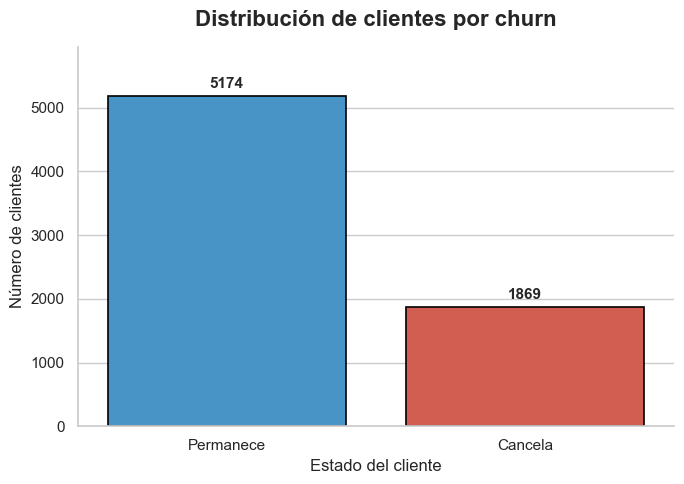

In [44]:
# Configurar estilo
sns.set_theme(style="whitegrid", context="notebook")

# Crear gráfica
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=data,
    x="Churn",
    order=[0, 1],
    hue="Churn",
    palette=["#3498DB", "#E74C3C"],
    legend=False,
    edgecolor="black",
    linewidth=1.2
)

# Agregar los valores encima de las barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4,
        fontsize=11,
        fontweight="bold"
    )

# Personalizar etiquetas
plt.title(
    "Distribución de clientes por churn",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Estado del cliente", fontsize=12)
plt.ylabel("Número de clientes", fontsize=12)

plt.xticks(
    ticks=[0, 1],
    labels=["Permanece", "Cancela"],
    rotation=0
)

# Dar espacio para las etiquetas
plt.ylim(0, data["Churn"].value_counts().max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

In [45]:
data["Churn"].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

## Interpretación de la distribución del target

El dataset presenta un **desbalance moderado** entre las clases.

La distribución no es de tipo 50/50, ya que la mayoría de los clientes permanecen activos y una proporción menor cancela el servicio.

## Implicaciones para la evaluación

Este desbalance será importante al evaluar los modelos.

Un clasificador que predijera siempre:

```text
Churn = 0
```

es decir, que todos los clientes permanecen activos, podría obtener aproximadamente:

```text
Accuracy ≈ 73.5%
```

Sin embargo, este modelo no detectaría ningún cliente que realmente canceló el servicio, por lo que sería poco útil para el área de Marketing.

## Métrica principal

Por esta razón, la métrica `AUC-ROC` será más informativa como métrica principal, tal como establece el proyecto.

También se revisarán métricas complementarias como:

- `Recall`, para medir cuántos clientes que cancelaron fueron detectados.
- `Precision`, para evaluar la exactitud de las predicciones positivas.
- `F1-score`, para equilibrar `Precision` y `Recall`.
- Matriz de confusión, para analizar los aciertos y errores de cada clase.

El objetivo no será únicamente maximizar el porcentaje general de aciertos, sino identificar correctamente a los clientes con mayor riesgo de cancelación.

### 6.4 Primera variable numérica: MonthlyCharges

**¿Los clientes que cancelan pagan cargos mensuales diferentes?**

In [46]:
# resumen estadístico

data.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


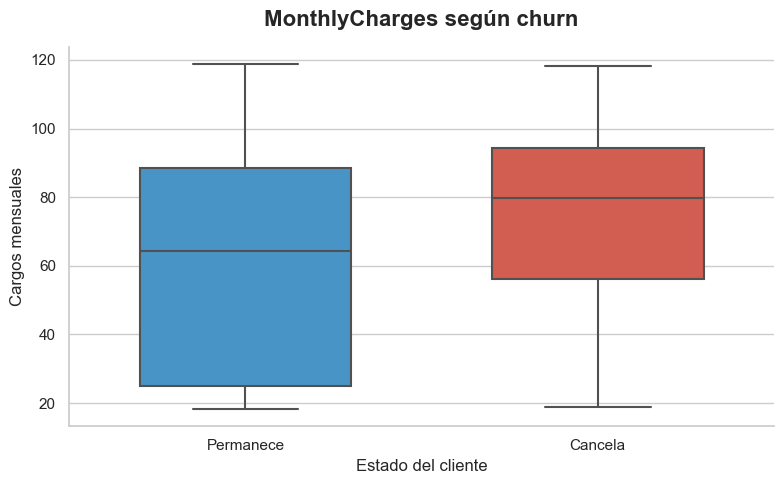

In [47]:
# Configurar estilo
sns.set_theme(style="whitegrid", context="notebook")

# Crear figura
plt.figure(figsize=(8, 5))

# Crear boxplot
ax = sns.boxplot(
    data=data,
    x="Churn",
    y="MonthlyCharges",
    order=[0, 1],
    hue="Churn",
    palette=["#3498DB", "#E74C3C"],
    legend=False,
    linewidth=1.5,
    width=0.6,
    fliersize=4
)

# Personalizar gráfica
plt.title(
    "MonthlyCharges según churn",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Estado del cliente", fontsize=12)
plt.ylabel("Cargos mensuales", fontsize=12)

plt.xticks(
    ticks=[0, 1],
    labels=["Permanece", "Cancela"]
)

sns.despine()
plt.tight_layout()
plt.show()

### ¿Los clientes que cancelan pagan cargos mensuales diferentes?

**Sí**, los clientes que cancelan el servicio pagan cargos mensuales notablemente diferentes y más elevados en comparación con los que permanecen en la empresa. 

A continuación, se detalla la justificación estadística basada en el diagrama de caja (*boxplot*):

*   **Mediana superior:** La línea central de la caja roja (**Cancela**) se ubica cerca de los **80**, mientras que la de la caja azul (**Permanece**) está en torno a los **65**. Esto demuestra que el cliente típico que abandona la compañía tiene un cargo mensual sustancialmente mayor.
*   **Dispersión y Concentración:** El 50% central de los clientes que cancelan (la altura de la caja roja) se concentra en un rango de precios altos, aproximadamente entre **56 y 94**. En contraste, la caja azul es mucho más amplia hacia abajo (rango de **25 a 88**), lo que indica que el grupo que permanece tiene una mayor diversidad de tarifas, incluyendo muchos clientes con planes económicos.
*   **Solapamiento sesgado:** Aunque existe un solapamiento entre ambos grupos, el tercer cuartil (la parte superior de la caja) de los clientes que se quedan coincide casi exactamente con la mediana (el centro) de los que se van. Esto significa que **el 50% de los clientes que cancelan pagan tarifas más altas que el 75% de los clientes que deciden quedarse**.
*   **Ausencia de valores extremos (Outliers):** No se observan puntos aislados por fuera de los bigotes en ninguno de los dos diagramas. Esto confirma que la diferencia observada es una tendencia generalizada de la distribución de los datos y no un efecto provocado por unos pocos clientes con tarifas atípicas.

#### Conclusión e Hipótesis de Negocio

Los resultados validan visualmente nuestra hipótesis: **Los clientes con cargos mensuales elevados presentan un riesgo de cancelación significativamente mayor.** 

*Nota de rigor analítico:* Es fundamental recordar que **asociación no implica causalidad**. Estos resultados no significan necesariamente que el precio alto sea la *causa única* del abandono; podría ocurrir que los usuarios con tarifas altas tengan contratados servicios más complejos que experimenten más fallas técnicas, o que simplemente sean más sensibles a ofertas de la competencia.

### 6.5 Distribución completa de MonthlyCharges

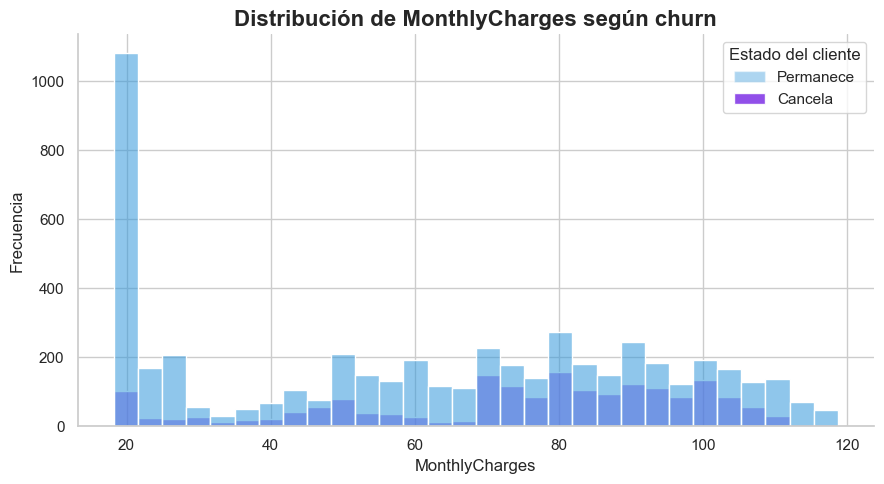

In [48]:
# histograma superpuesto

from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="MonthlyCharges",
    hue="Churn",
    hue_order=[0, 1],
    bins=30,
    multiple="layer",
    alpha=0.55,
    palette=["#3498DB", "#853CE7"],
    edgecolor="white"
)

leyenda = [
    Patch(facecolor="#3498DB", alpha=0.40, label="Permanece"),
    Patch(facecolor="#853CE7", alpha=0.90, label="Cancela")
]

plt.legend(
    handles=leyenda,
    title="Estado del cliente"
)

plt.title(
    "Distribución de MonthlyCharges según churn",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("MonthlyCharges")
plt.ylabel("Frecuencia")

sns.despine()
plt.tight_layout()
plt.show()

### Análisis de la distribución de cargos mensuales según `Churn`

El histograma superpuesto permite evaluar el volumen y la distribución de los clientes según sus cargos mensuales. Esta visualización aporta detalles que los promedios pueden ocultar.

## Interpretación del comportamiento

- **Concentración en la tarifa básica cercana a 20:** Existe una concentración importante de clientes alrededor de los 20 dólares mensuales, con más de 1,000 usuarios. En este rango, la cantidad de cancelaciones es baja en comparación con el volumen total de clientes. Esto puede indicar que los planes básicos y económicos presentan una mayor estabilidad o un menor incentivo para cambiar de compañía.

- **Distribución del riesgo en cargos altos, entre 70 y 100:** A partir de aproximadamente 70 dólares mensuales, el grupo de clientes que cancela aparece de forma constante y representa una proporción visualmente relevante. No se observa un único punto máximo de cancelaciones, sino una distribución sostenida en distintos niveles de cargos entre 70 y 100 dólares.

- **Comportamiento bimodal de los clientes activos:** El grupo de clientes que permanece activo presenta dos acumulaciones principales: una concentración masiva alrededor de los 20 dólares y otra distribución secundaria entre los 70 y 100 dólares.

- **Ausencia del segmento de bajo costo entre los clientes que cancelan:** El grupo que cancela presenta una presencia mucho menor en el rango de cargos bajos y concentra una mayor parte de sus observaciones en los niveles de precio medio-altos y altos.

## Conclusión analítica

El gráfico sugiere que el riesgo de cancelación no aumenta necesariamente de forma lineal, sino que puede presentar cambios por segmentos de precio.

Se observa una posible **zona de menor riesgo** por debajo de los 30 dólares mensuales. En cambio, cuando los cargos mensuales superan aproximadamente los 70 dólares, la presencia relativa de clientes que cancelan parece aumentar de manera sostenida.

Este resultado sugiere investigar con mayor detalle los segmentos de facturación media-alta y alta, considerando variables adicionales como:

- Tipo de contrato.
- Antigüedad del cliente.
- Número de servicios contratados.
- Servicio de internet.
- Contratación de soporte técnico.
- Calidad percibida del servicio.

Es importante señalar que el histograma muestra una asociación visual, pero no demuestra por sí solo que los cargos mensuales causen la cancelación. Esta relación deberá validarse mediante tasas de `Churn` por intervalos y mediante el modelo predictivo.

### 6.6 TotalCharges

In [49]:
data.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
1,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


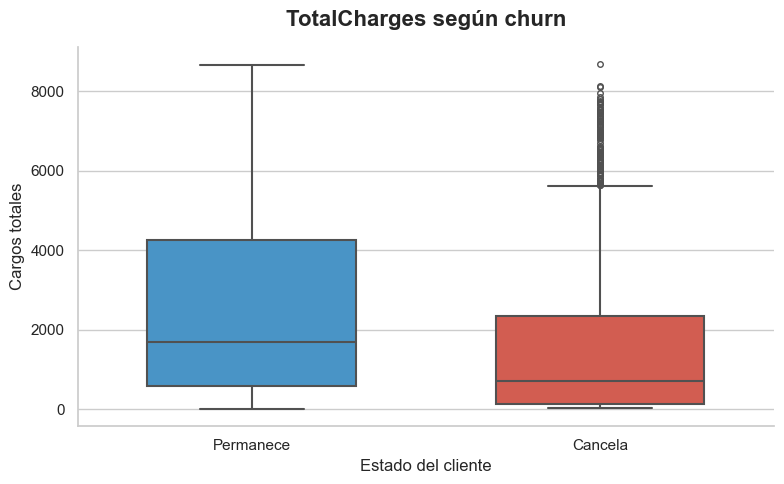

In [50]:
# Configurar estilo
sns.set_theme(style="whitegrid", context="notebook")

# Crear figura
plt.figure(figsize=(8, 5))

# Crear boxplot
ax = sns.boxplot(
    data=data,
    x="Churn",
    y="TotalCharges",
    order=[0, 1],
    hue="Churn",
    palette={
        0: "#3498DB",
        1: "#E74C3C"
    },
    legend=False,
    width=0.6,
    linewidth=1.5,
    fliersize=4
)

# Personalizar etiquetas
plt.title(
    "TotalCharges según churn",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Estado del cliente", fontsize=12)
plt.ylabel("Cargos totales", fontsize=12)

plt.xticks(
    ticks=[0, 1],
    labels=["Permanece", "Cancela"]
)

sns.despine()
plt.tight_layout()
plt.show()

### ¿Los clientes que cancelan acumulan cargos totales diferentes?

Sí. El comportamiento de los cargos totales acumulados (`TotalCharges`) es diferente entre los clientes que cancelan y los que permanecen activos. El grupo que abandona presenta, en general, valores acumulados considerablemente menores.

## Interpretación del diagrama de caja

- **Mediana marcadamente inferior:** La mediana del grupo que cancela se encuentra por debajo de los 700 dólares, mientras que la mediana del grupo que permanece supera los 1,700 dólares. Esto indica que una parte importante de los clientes que abandonan lo hace después de haber acumulado una facturación relativamente baja.

- **Asimetría y concentración en valores bajos:** El 75 % de los clientes que cancelan se encuentra por debajo de aproximadamente 2,400 dólares en cargos totales. Este patrón sugiere una posible relación entre la cancelación y ciclos de vida más cortos.

- **Presencia de valores atípicos:** El grupo de cancelación presenta valores extremos que se extienden aproximadamente desde 5,600 hasta 8,000 dólares. Estos casos representan clientes de alto valor que abandonaron el servicio después de acumular una facturación considerable.

## Conclusión e hipótesis de negocio

La combinación de este análisis con los resultados observados en `MonthlyCharges` permite formular la siguiente hipótesis:

> **El riesgo de cancelación podría concentrarse especialmente en clientes nuevos con cargos mensuales elevados.**

Estos clientes comienzan con mensualidades altas y podrían cancelar antes de acumular una cantidad significativa de cargos totales.

Los valores atípicos del grupo de cancelación también representan una señal importante para el negocio, ya que corresponden a clientes de alto valor que abandonaron Interconnect después de una relación prolongada.

Por ello, convendría investigar por separado:

- Clientes nuevos con cargos mensuales altos.
- Clientes antiguos con cargos totales elevados.
- Clientes de alto valor que cancelaron.
- Relación entre `TotalCharges`, `MonthlyCharges` y `Tenure`.
- Influencia del tipo de contrato en estos patrones.

## Precaución metodológica

`TotalCharges` está relacionado con el tiempo que el cliente lleva en la empresa. Por esta razón, no debe interpretarse de forma aislada como evidencia de causalidad.

El gráfico muestra una asociación descriptiva, pero será necesario contrastarla con la antigüedad (`Tenure`), el tipo de contrato y otras variables mediante el modelo predictivo.

### 6.7 Tipo de contrato

**¿La tasa de churn cambia según el tipo de contrato?**

In [51]:
contract_churn = (
    data.groupby("Type")["Churn"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

contract_churn

,mean,count
Type,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


In [52]:
# Ver lo como porcentaje

contract_churn["churn_rate_pct"] = (
    contract_churn["mean"] * 100
)

contract_churn

,mean,count,churn_rate_pct
Type,,,
Month-to-month,0.427097,3875,42.709677
One year,0.112695,1473,11.269518
Two year,0.028319,1695,2.831858


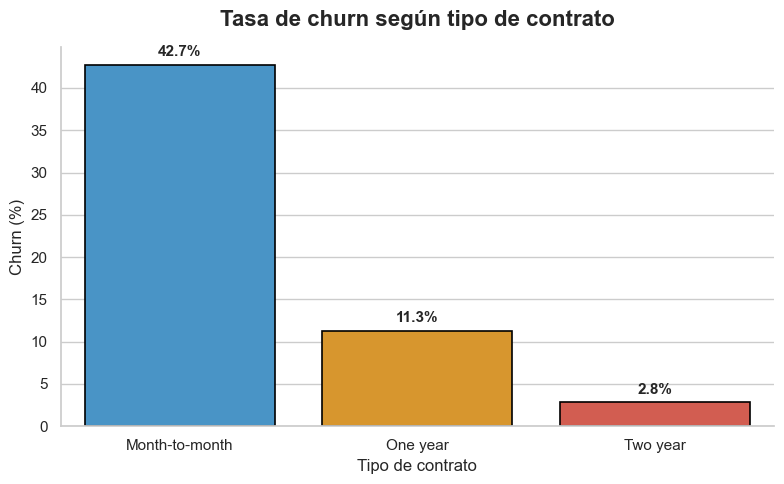

In [53]:
# Calcular tasa de churn por tipo de contrato
contract_churn = (
    data
    .groupby("Type")["Churn"]
    .agg(["size", "sum"])
    .assign(
        churn_rate_pct=lambda df: df["sum"] / df["size"] * 100
    )
    .reset_index()
)

# Configurar estilo
sns.set_theme(style="whitegrid", context="notebook")

# Crear figura
plt.figure(figsize=(8, 5))

# Gráfica de barras con seaborn
ax = sns.barplot(
    data=contract_churn,
    x="Type",
    y="churn_rate_pct",
    hue="Type",
    palette=["#3498DB", "#F39C12", "#E74C3C"],
    legend=False,
    edgecolor="black",
    linewidth=1.2
)

# Agregar valores sobre las barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4,
        fontsize=11,
        fontweight="bold"
    )

# Personalizar etiquetas
plt.title(
    "Tasa de churn según tipo de contrato",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Tipo de contrato", fontsize=12)
plt.ylabel("Churn (%)", fontsize=12)

plt.xticks(rotation=0)

sns.despine()
plt.tight_layout()
plt.show()

## Análisis de negocio: tipo de contrato y `Churn`

Aquí comienza la interpretación desde la perspectiva de negocio.

Supongamos que observamos el siguiente comportamiento:

| Tipo de contrato | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `Month-to-month` | 0.43 | 3,875 | 42.71 % |
| `One year` | 0.11 | 1,473 | 11.27 % |
| `Two year` | 0.03 | 1,695 | 2.83 % |

Los datos muestran que los clientes con contratos mensuales presentan una tasa de cancelación considerablemente mayor que aquellos con contratos de uno o dos años.

También se observa que la tasa de `Churn` disminuye conforme aumenta la duración del contrato.

## Interpretación correcta

No debemos concluir:

> **“El contrato de dos años evita el `Churn`.”**

Con estos datos, únicamente podemos afirmar:

> **“En este conjunto de datos, los clientes con contratos de mayor duración presentan una menor tasa de cancelación.”**

Esta afirmación describe una asociación observada, pero no demuestra que la duración del contrato sea la causa directa de la menor cancelación.

## Correlación y causalidad

Puede existir un efecto de selección:

- Los clientes más comprometidos con la empresa podrían ser precisamente quienes eligen contratos largos.
- Los clientes con menor compromiso podrían preferir contratos mensuales porque ofrecen mayor flexibilidad.
- Otros factores, como la antigüedad, el precio, los servicios contratados o el método de pago, podrían influir simultáneamente en la elección del contrato y en el `Churn`.

Por lo tanto:

```text
Correlación ≠ Causalidad
```

El tipo de contrato parece ser una variable predictivamente relevante, pero será necesario analizarla junto con el resto de las características para comprender mejor el riesgo de cancelación.

## Implicación para Marketing

Los clientes con contrato mensual podrían considerarse un segmento prioritario para estrategias de retención.

Algunas acciones posibles serían:

- Ofrecer incentivos para migrar a contratos anuales.
- Diseñar promociones específicas para clientes mensuales.
- Identificar clientes mensuales con cargos altos o poca antigüedad.
- Ofrecer beneficios adicionales antes de que evalúen cancelar.
- Priorizar estos clientes utilizando la probabilidad individual de `Churn`.

Estas acciones deben evaluarse mediante experimentos o análisis posteriores para comprobar si realmente reducen la cancelación.

### 6.8 Método de pago

**¿Existe algún método de pago claramente asociado con una mayor tasa de churn?**

In [54]:
payment_churn = (
    data.groupby("PaymentMethod")["Churn"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

payment_churn["churn_rate_pct"] = (
    payment_churn["mean"] * 100
)

payment_churn

,mean,count,churn_rate_pct
PaymentMethod,,,
Electronic check,0.452854,2365,45.285412
Mailed check,0.191067,1612,19.106700
Bank transfer (automatic),0.167098,1544,16.709845
Credit card (automatic),0.152431,1522,15.243101


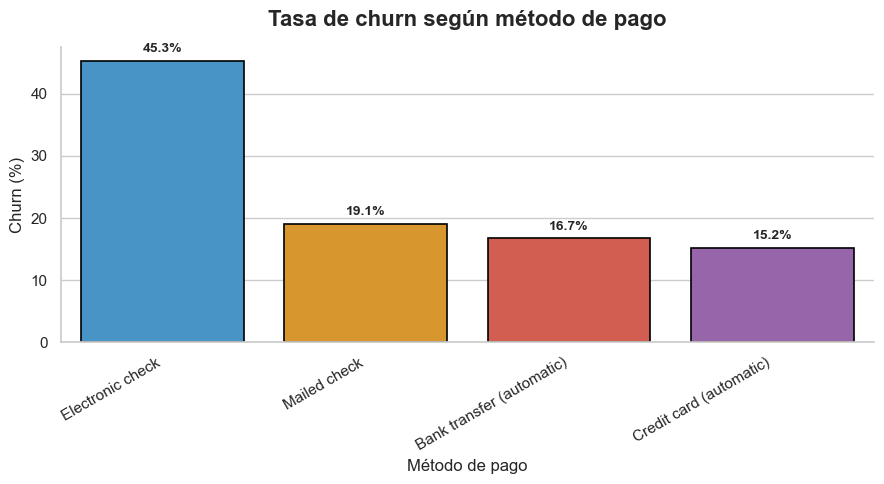

In [55]:
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="churn_rate_pct",
    hue="PaymentMethod",
    palette=["#3498DB", "#F39C12", "#E74C3C", "#9B59B6"],
    legend=False,
    edgecolor="black",
    linewidth=1.2
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Tasa de churn según método de pago",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Método de pago", fontsize=12)
plt.ylabel("Churn (%)", fontsize=12)

plt.xticks(rotation=30, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

## Análisis empresarial: método de pago y `Churn`

### Pregunta empresarial

> **¿Existe algún método de pago claramente asociado con una mayor tasa de `Churn`?**

Responder esta pregunta permitirá identificar si ciertos métodos de pago están relacionados con una mayor probabilidad de cancelación y si pueden ser útiles para priorizar clientes durante el modelado.

## Resultados observados

| Método de pago | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `Electronic check` | 0.45 | 2,365 | 45.29 % |
| `Mailed check` | 0.19 | 1,612 | 19.11 % |
| `Bank transfer (automatic)` | 0.17 | 1,544 | 16.71 % |
| `Credit card (automatic)` | 0.15 | 1,522 | 15.24 % |

El método de pago `Electronic check` presenta la tasa de cancelación más alta, con aproximadamente **45.29 %**.

Los métodos de pago automáticos presentan tasas considerablemente menores:

- `Bank transfer (automatic)`: 16.71 %.
- `Credit card (automatic)`: 15.24 %.

El método `Mailed check` presenta una tasa intermedia de cancelación, cercana al 19.11 %.

## Interpretación inicial

En estos datos, el método `Electronic check` aparece claramente asociado con una mayor tasa de `Churn`.

Esto podría indicar diferencias en:

- El nivel de vinculación del cliente con la empresa.
- La facilidad o dificultad para realizar pagos recurrentes.
- El perfil de los clientes que eligen este método.
- La duración de sus contratos.
- Sus cargos mensuales.
- Su antigüedad dentro de Interconnect.

Sin embargo, este resultado representa una asociación y no demuestra que el método de pago sea la causa directa de la cancelación.

## Posibles variables relacionadas

Antes de interpretar el método de pago como un factor independiente, será necesario analizar posibles relaciones entre:

```text
PaymentMethod
        ↕
Contract Type
        ↕
MonthlyCharges
```

Por ejemplo, el método `Electronic check` podría estar más concentrado entre clientes con contratos `Month-to-month`, que ya presentan una tasa elevada de cancelación.

También es posible que determinados métodos de pago sean más frecuentes entre clientes nuevos o con cargos mensuales específicos.

## Hipótesis de negocio

> **Los clientes que utilizan `Electronic check` presentan una mayor tasa de cancelación, posiblemente en combinación con contratos mensuales, menor antigüedad o cargos mensuales elevados.**

Esta hipótesis deberá investigarse mediante análisis cruzados y posteriormente evaluarse dentro del modelo predictivo.

## Implicación para Marketing

El grupo de clientes que utiliza `Electronic check` podría considerarse un segmento de atención prioritaria.

Marketing podría evaluar acciones como:

- Promover métodos de pago automáticos.
- Ofrecer incentivos para cambiar a transferencia o tarjeta automática.
- Revisar si existen problemas de fricción en el proceso de pago electrónico.
- Analizar este segmento junto con el tipo de contrato y los cargos mensuales.

La recomendación final deberá basarse en el análisis combinado de las variables y no únicamente en el método de pago.

### 6.9 Facturación electrónica

**¿Los clientes con factura electrónica presentan una tasa de churn diferente?**


In [56]:
paperless_churn = (
    data.groupby("PaperlessBilling")["Churn"]
    .agg(["mean", "count"])
)

paperless_churn["churn_rate_pct"] = (
    paperless_churn["mean"] * 100
)

paperless_churn

,mean,count,churn_rate_pct
PaperlessBilling,,,
No,0.163301,2872,16.330084
Yes,0.335651,4171,33.565092


## Análisis empresarial: factura electrónica y `Churn`

### Pregunta empresarial

> **¿Los clientes con factura electrónica presentan una tasa de `Churn` diferente?**

Esta pregunta permitirá evaluar si existe una asociación entre el uso de factura electrónica y la cancelación del servicio.

## Resultados observados

| Facturación electrónica | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.16 | 2,872 | 16.33 % |
| `Yes` | 0.34 | 4,171 | 33.57 % |

Los clientes que utilizan factura electrónica presentan una tasa de cancelación aproximada del **33.57 %**, mientras que los clientes que no la utilizan presentan una tasa cercana al **16.33 %**.

Por lo tanto, en estos datos, la tasa de `Churn` es mayor entre los clientes con facturación electrónica.

## Interpretación inicial

Existe una diferencia descriptiva importante entre ambos grupos:

- Clientes sin factura electrónica: menor tasa de cancelación.
- Clientes con factura electrónica: mayor tasa de cancelación.

Esta diferencia puede hacer que `PaperlessBilling` sea una variable potencialmente útil para el modelo predictivo.

Sin embargo, todavía no se debe afirmar que la factura electrónica cause la cancelación.

## Correlación no implica causalidad

El uso de factura electrónica podría estar relacionado con otras características del cliente, como:

- Tipo de contrato.
- Método de pago.
- Antigüedad.
- Cargos mensuales.
- Tipo de servicio de internet.
- Perfil demográfico.
- Número de servicios contratados.

Por ejemplo, es posible que los clientes con facturación electrónica también utilicen con mayor frecuencia `Electronic check` o tengan contratos mensuales.

Por lo tanto, el resultado debe interpretarse como una asociación observada:

```text
PaperlessBilling = Yes
→ mayor tasa observada de Churn
```

No como una relación causal.

## Hipótesis de negocio

> **Los clientes que utilizan factura electrónica presentan una mayor tasa de cancelación, posiblemente porque pertenecen a segmentos con contratos mensuales, cargos elevados o menor antigüedad.**

Esta hipótesis deberá investigarse mediante análisis cruzados y evaluarse posteriormente dentro del modelo predictivo.

## Implicación para Marketing

El segmento con factura electrónica podría incorporarse a las reglas de priorización, especialmente cuando se combine con otros factores de riesgo.

Por ejemplo, podría prestarse atención a clientes que cumplan simultáneamente con las siguientes condiciones:

- Utilizan factura electrónica.
- Tienen un contrato mensual.
- Presentan cargos mensuales elevados.
- Poseen poca antigüedad.

La decisión final deberá basarse en el comportamiento combinado de las variables y no únicamente en `PaperlessBilling`.

### 6.10 Variables personales

In [57]:
personal_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

In [58]:
# función para no repetir código

def churn_rate_by_category(df, column):
    result = (
        df.groupby(column)["Churn"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    result["churn_rate_pct"] = result["mean"] * 100

    return result

In [59]:
for column in personal_columns:
    print(f"\n{column}")
    display(churn_rate_by_category(data, column))


gender


,mean,count,churn_rate_pct
gender,,,
Female,0.269209,3488,26.920872
Male,0.261603,3555,26.160338



SeniorCitizen


,mean,count,churn_rate_pct
SeniorCitizen,,,
1,0.416813,1142,41.681261
0,0.236062,5901,23.606168



Partner


,mean,count,churn_rate_pct
Partner,,,
No,0.329580,3641,32.957979
Yes,0.196649,3402,19.664903



Dependents


,mean,count,churn_rate_pct
Dependents,,,
No,0.312791,4933,31.279140
Yes,0.154502,2110,15.450237


## 6.11 Análisis de variables personales

El objetivo es analizar si las características personales de los clientes están asociadas con diferentes tasas de `Churn`.

No se estudiará únicamente si existen diferencias entre grupos. También se evaluará la magnitud de esas diferencias y su posible relevancia para el negocio.

## Resultados observados

### Género

| Género | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `Female` | 0.27 | 3,488 | 26.92 % |
| `Male` | 0.26 | 3,555 | 26.16 % |

La diferencia entre ambos grupos es pequeña:

```text
26.92% - 26.16% = 0.76 puntos porcentuales
```

Por lo tanto, el género no presenta una diferencia descriptiva importante en la tasa de cancelación.

### Adulto mayor

| `SeniorCitizen` | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---:|---:|---:|---:|
| `1` | 0.42 | 1,142 | 41.68 % |
| `0` | 0.24 | 5,901 | 23.61 % |

Los clientes adultos mayores presentan una tasa de cancelación considerablemente superior:

```text
41.68% frente a 23.61%
```

La diferencia es de aproximadamente **18.07 puntos porcentuales**.

Este resultado sugiere que `SeniorCitizen` podría ser una variable potencialmente relevante para la predicción.

### Pareja

| `Partner` | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.33 | 3,641 | 32.96 % |
| `Yes` | 0.20 | 3,402 | 19.66 % |

Los clientes sin pareja presentan una tasa de cancelación mayor:

```text
32.96% frente a 19.66%
```

La diferencia es de aproximadamente **13.30 puntos porcentuales**.

### Dependientes

| `Dependents` | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.31 | 4,933 | 31.28 % |
| `Yes` | 0.15 | 2,110 | 15.45 % |

Los clientes sin dependientes presentan una tasa de cancelación superior:

```text
31.28% frente a 15.45%
```

La diferencia es de aproximadamente **15.83 puntos porcentuales**.

## ¿Qué buscamos en las variables personales?

No basta con comprobar si dos grupos tienen tasas diferentes. También debemos evaluar si la diferencia tiene una magnitud potencialmente relevante.

Por ejemplo:

```text
26% frente a 27%
```

representa una diferencia pequeña y posiblemente poco útil para tomar decisiones.

En cambio:

```text
15% frente a 40%
```

representa una diferencia considerablemente mayor y puede justificar una investigación adicional.

## Diferencia estadística y relevancia de negocio

Es importante distinguir entre:

- **Diferencia existente:** las tasas de cancelación no son exactamente iguales.
- **Diferencia potencialmente relevante:** la separación entre las tasas es suficientemente grande como para influir en la priorización o en una estrategia comercial.

## Hipótesis de negocio

Los resultados sugieren que los siguientes segmentos podrían presentar mayor riesgo de cancelación:

- Clientes adultos mayores.
- Clientes sin pareja.
- Clientes sin dependientes.

Sin embargo, estas variables no deben interpretarse como causas directas de cancelación. Las diferencias podrían estar relacionadas con otras características, como el tipo de contrato, la antigüedad, los cargos mensuales o los servicios contratados.

Por lo tanto, las variables personales deberán analizarse conjuntamente con el resto de las características y evaluarse posteriormente dentro del modelo predictivo.

### 6.12 InternetService

In [60]:
internet_service_churn = (
    churn_rate_by_category(
        data,
        "InternetService"
    )
)

internet_service_churn

,mean,count,churn_rate_pct
InternetService,,,
Fiber optic,0.418928,3096,41.892765
DSL,0.189591,2421,18.959108
No internet service,0.074050,1526,7.404980


## Análisis empresarial: tipo de servicio de Internet y `Churn`

La variable `InternetService` presenta tres categorías:

- `DSL`
- `Fiber optic`
- `No internet service`

Esta tercera categoría se obtuvo al interpretar los valores ausentes después del `LEFT JOIN`. La ausencia de registro en la tabla `internet` representa que el cliente no tiene contratado el servicio de internet.

## Resultados observados

| Tipo de servicio de internet | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `Fiber optic` | 0.42 | 3,096 | 41.89 % |
| `DSL` | 0.19 | 2,421 | 18.96 % |
| `No internet service` | 0.07 | 1,526 | 7.40 % |

Los clientes con fibra óptica presentan la tasa de cancelación más alta, con aproximadamente **41.89 %**.

En comparación:

- Los clientes con DSL presentan una tasa de cancelación de **18.96 %**.
- Los clientes sin servicio de internet presentan una tasa de cancelación de **7.40 %**.

## Interpretación de las categorías

Es importante conservar las tres categorías porque representan situaciones comerciales diferentes:

| Categoría | Interpretación |
|---|---|
| `DSL` | El cliente tiene contratado internet mediante tecnología DSL. |
| `Fiber optic` | El cliente tiene contratado internet mediante fibra óptica. |
| `No internet service` | El cliente no tiene contratado ningún servicio de internet. |

Si los valores ausentes se hubieran reemplazado simplemente por:

```text
No
```

se habría perdido la diferencia entre:

- Un cliente que tiene internet, pero no contrató un servicio adicional.
- Un cliente que no tiene contratado ningún servicio de internet.

## Evidencia

> **Los clientes con fibra óptica presentan una tasa de churn de 41.89 %, mayor que los clientes DSL..**

## Hipótesis

> Esta diferencia podría estar asociada con precio, características del cliente, contrato u otros factores no observados.


## Importancia para el modelo

La variable `InternetService` parece potencialmente útil para predecir `Churn`.

Su valor predictivo se debe precisamente a que distingue entre:

```text
Tipo de conexión
```

y:

```text
Ausencia completa del servicio de internet
```

Esta representación conserva la información empresarial de los datos y evita perder señales potencialmente relevantes para el análisis.

### 6.13 Servicios adicionales

In [61]:
internet_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [62]:
for column in internet_features:
    print(f"\n{column}")
    display(churn_rate_by_category(data, column))


OnlineSecurity


,mean,count,churn_rate_pct
OnlineSecurity,,,
No,0.417667,3498,41.766724
Yes,0.146112,2019,14.611194
No internet service,0.074050,1526,7.404980



OnlineBackup


,mean,count,churn_rate_pct
OnlineBackup,,,
No,0.399288,3088,39.928756
Yes,0.215315,2429,21.531494
No internet service,0.074050,1526,7.404980



DeviceProtection


...

,mean,count,churn_rate_pct
TechSupport,,,
No,0.416355,3473,41.635474
Yes,0.151663,2044,15.166341
No internet service,0.074050,1526,7.404980



StreamingTV


,mean,count,churn_rate_pct
StreamingTV,,,
No,0.335231,2810,33.523132
Yes,0.300702,2707,30.070188
No internet service,0.074050,1526,7.404980



StreamingMovies


,mean,count,churn_rate_pct
StreamingMovies,,,
No,0.336804,2785,33.680431
Yes,0.299414,2732,29.941435
No internet service,0.074050,1526,7.404980


## Análisis empresarial de los servicios de Internet

Las variables relacionadas con los servicios adicionales de internet presentan tres categorías:

- `Yes`: el cliente contrató el servicio.
- `No`: el cliente tiene internet, pero no contrató el servicio adicional.
- `No internet service`: el cliente no tiene contratado el servicio de internet.

Esta diferenciación permite conservar el significado empresarial de los valores ausentes.

## Resultados observados

### `OnlineSecurity`

| Categoría | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.42 | 3,498 | 41.77 % |
| `Yes` | 0.15 | 2,019 | 14.61 % |
| `No internet service` | 0.07 | 1,526 | 7.40 % |

Los clientes que no contrataron seguridad en línea presentan una tasa de cancelación considerablemente mayor que quienes sí la contrataron.

### `OnlineBackup`

| Categoría | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.40 | 3,088 | 39.93 % |
| `Yes` | 0.22 | 2,429 | 21.53 % |
| `No internet service` | 0.07 | 1,526 | 7.40 % |

La contratación de respaldo en línea se asocia con una tasa de cancelación menor.

### `DeviceProtection`

| Categoría | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.39 | 3,095 | 39.13 % |
| `Yes` | 0.23 | 2,422 | 22.50 % |
| `No internet service` | 0.07 | 1,526 | 7.40 % |

Los clientes que contrataron protección para dispositivos presentan una menor tasa de cancelación que aquellos que no contrataron este servicio.

### `TechSupport`

| Categoría | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.42 | 3,473 | 41.64 % |
| `Yes` | 0.15 | 2,044 | 15.17 % |
| `No internet service` | 0.07 | 1,526 | 7.40 % |

La ausencia de soporte técnico contratado se asocia con una tasa de cancelación notablemente mayor.

### `StreamingTV`

| Categoría | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.34 | 2,810 | 33.52 % |
| `Yes` | 0.30 | 2,707 | 30.07 % |
| `No internet service` | 0.07 | 1,526 | 7.40 % |

La diferencia entre los clientes que tienen y no tienen `StreamingTV` es relativamente pequeña. Sin embargo, ambos grupos presentan una tasa mayor que los clientes sin servicio de internet.

### `StreamingMovies`

| Categoría | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `No` | 0.34 | 2,785 | 33.68 % |
| `Yes` | 0.30 | 2,732 | 29.94 % |
| `No internet service` | 0.07 | 1,526 | 7.40 % |

Al igual que en `StreamingTV`, la diferencia entre contratar o no contratar el servicio es moderada.

## Interpretación general

Los servicios de seguridad en línea, respaldo, protección de dispositivos y soporte técnico muestran diferencias importantes en las tasas de cancelación.

En general, los clientes que no contrataron estos servicios presentan tasas de `Churn` más altas, mientras que los clientes que sí los contrataron presentan tasas menores.

Los clientes sin servicio de internet muestran consistentemente una tasa de cancelación de aproximadamente **7.40 %** en todas estas variables.

## Hipótesis de negocio

> **Los clientes que contratan servicios adicionales de protección, respaldo y soporte técnico podrían presentar una mayor vinculación con Interconnect y una menor tasa de cancelación.**

Otra hipótesis posible es:

> **Los clientes con internet que no contratan servicios adicionales podrían representar un segmento con mayor riesgo de abandono.**

Estas hipótesis deberán validarse mediante el modelado predictivo y análisis adicionales.

## Precaución metodológica

Los servicios contratados pueden estar correlacionados entre sí.

Por ejemplo, un cliente que contrata `OnlineSecurity` también podría tener mayor probabilidad de contratar:

- `OnlineBackup`.
- `DeviceProtection`.
- `TechSupport`.

Por esta razón, no se debe asumir que cada servicio tiene un efecto independiente sobre el `Churn`.

Los análisis individuales muestran asociaciones descriptivas, pero no permiten separar completamente la influencia de las variables relacionadas. El modelo predictivo, al utilizar varias características simultáneamente, permitirá evaluar mejor qué variables contribuyen a distinguir a los clientes en riesgo.

### 6.14 Telefonía

In [63]:
churn_rate_by_category(
    data,
    "MultipleLines"
)

,mean,count,churn_rate_pct
MultipleLines,,,
Yes,0.286099,2971,28.609896
No,0.250442,3390,25.044248
No phone service,0.249267,682,24.926686


## Análisis empresarial: múltiples líneas telefónicas y `Churn`

La variable `MultipleLines` presenta tres categorías:

- `Yes`: el cliente tiene servicio telefónico y múltiples líneas.
- `No`: el cliente tiene servicio telefónico, pero una sola línea.
- `No phone service`: el cliente no tiene contratado el servicio telefónico.

## Resultados observados

| Categoría | Tasa media de `Churn` | Cantidad de clientes | Tasa de cancelación |
|---|---:|---:|---:|
| `Yes` | 0.29 | 2,971 | 28.61 % |
| `No` | 0.25 | 3,390 | 25.04 % |
| `No phone service` | 0.25 | 682 | 24.93 % |

## Pregunta empresarial

> **¿Tener múltiples líneas telefónicas parece estar asociado con una mayor tasa de `Churn`?**

Los clientes con múltiples líneas presentan una tasa de cancelación de aproximadamente **28.61 %**, superior a la observada en:

- Clientes con una sola línea: **25.04 %**.
- Clientes sin servicio telefónico: **24.93 %**.

La diferencia entre tener múltiples líneas y tener una sola línea es de aproximadamente:

```text
28.61% - 25.04% = 3.57 puntos porcentuales
```

## Interpretación inicial

En estos datos, los clientes con múltiples líneas presentan una tasa de cancelación ligeramente mayor.

Sin embargo, la diferencia es moderada y menor que la observada en otras variables, como:

- Tipo de contrato.
- Método de pago.
- Servicio de internet.
- Soporte técnico.
- Seguridad en línea.

Por lo tanto, `MultipleLines` podría aportar información al modelo, pero probablemente deba interpretarse junto con otras características.

## Hipótesis de negocio

> **Los clientes con múltiples líneas podrían presentar un riesgo de cancelación ligeramente superior, posiblemente debido a cargos mensuales más altos o a mayores expectativas sobre el servicio.**

También es posible que el efecto observado se deba a otras variables relacionadas, como:

- Tipo de contrato.
- Cargos mensuales.
- Antigüedad.
- Cantidad total de servicios.
- Tipo de internet contratado.

El análisis descriptivo muestra una asociación, pero no permite concluir que tener múltiples líneas cause la cancelación.

### 6.15 Crear una tabla resumen categórica

In [64]:
categorical_columns = [
    "Type",
    "PaperlessBilling",
    "PaymentMethod",
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "MultipleLines"
]

In [65]:
for column in categorical_columns:
    result = churn_rate_by_category(data, column)

    print("\n", "=" * 60)
    print(column)
    print("=" * 60)

    display(result)


Type


,mean,count,churn_rate_pct
Type,,,
Month-to-month,0.427097,3875,42.709677
One year,0.112695,1473,11.269518
Two year,0.028319,1695,2.831858



PaperlessBilling


,mean,count,churn_rate_pct
PaperlessBilling,,,
Yes,0.335651,4171,33.565092
No,0.163301,2872,16.330084



PaymentMethod


...

,mean,count,churn_rate_pct
StreamingTV,,,
No,0.335231,2810,33.523132
Yes,0.300702,2707,30.070188
No internet service,0.074050,1526,7.404980



StreamingMovies


,mean,count,churn_rate_pct
StreamingMovies,,,
No,0.336804,2785,33.680431
Yes,0.299414,2732,29.941435
No internet service,0.074050,1526,7.404980



MultipleLines


,mean,count,churn_rate_pct
MultipleLines,,,
Yes,0.286099,2971,28.609896
No,0.250442,3390,25.044248
No phone service,0.249267,682,24.926686


### 6.16 Comprobación importante: tamaño de los grupos

Al analizar las tasas de `Churn` por categoría, no debemos observar únicamente el porcentaje de cancelación.

También es fundamental conocer cuántos clientes pertenecen a cada grupo.

## Ejemplo

Supongamos que obtenemos los siguientes resultados:

| Categoría | Tasa de `Churn` | Número de clientes |
|---|---:|---:|
| Categoría A | 60 % | 5 |
| Categoría B | 25 % | 1,000 |

A primera vista, la Categoría A parece presentar un riesgo mucho mayor.

Sin embargo, la Categoría A contiene únicamente cinco clientes. Una tasa calculada sobre un grupo tan pequeño puede ser inestable y no representar un patrón generalizable.

## Importancia de incluir `count`

Por esta razón, cada análisis de tasas de cancelación incluirá como mínimo:

- `mean`: tasa media de `Churn`.
- `count`: número de clientes del grupo.
- `churn_rate_pct`: tasa de cancelación expresada como porcentaje.

Por ejemplo:

| Categoría | Mean | Count | Churn rate (%) |
|---|---:|---:|---:|
| Categoría A | 0.60 | 5 | 60 % |
| Categoría B | 0.25 | 1,000 | 25 % |

## Regla de interpretación

No se debe interpretar una tasa de cancelación sin conocer el tamaño del grupo que la produce.

La pregunta correcta no es únicamente:

> **¿Qué categoría tiene la mayor tasa de `Churn`?**

También debemos preguntar:

> **¿Cuántos clientes pertenecen a esa categoría y qué tan confiable es la tasa observada?**

Esta comprobación ayuda a evitar conclusiones exageradas basadas en grupos pequeños y permite priorizar patrones que aparecen en una cantidad suficiente de clientes.

### 6.17 Relación MonthlyCharges y tipo de contrato

**¿Los cargos mensuales también cambian según el tipo de contrato?**

In [66]:
data.groupby("Type")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Month-to-month,3875.0,66.398490,26.926599,18.75,45.850,73.25,88.875,117.45
One year,1473.0,65.048608,31.840539,18.25,26.900,68.75,94.800,118.60
Two year,1695.0,60.770413,34.678865,18.40,24.025,64.35,90.450,118.75


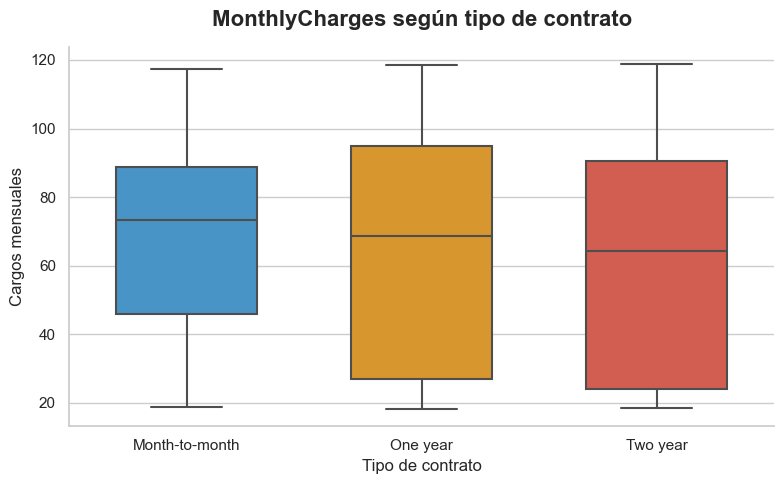

In [67]:
# Configurar estilo
sns.set_theme(style="whitegrid", context="notebook")

# Crear figura
plt.figure(figsize=(8, 5))

# Boxplot con seaborn
ax = sns.boxplot(
    data=data,
    x="Type",
    y="MonthlyCharges",
    hue="Type",
    palette=["#3498DB", "#F39C12", "#E74C3C"],
    legend=False,
    linewidth=1.5,
    width=0.6,
    fliersize=4
)

# Personalizar etiquetas
plt.title(
    "MonthlyCharges según tipo de contrato",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Tipo de contrato", fontsize=12)
plt.ylabel("Cargos mensuales", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

### Análisis de cargos mensuales según el tipo de contrato

El análisis de los cargos mensuales distribuidos por tipo de contrato permite observar cómo la flexibilidad contractual se relaciona con las tarifas pagadas por los clientes.

## Interpretación de las distribuciones

- **Mayor costo mensual en contratos de corto plazo:** El contrato `Month-to-month` presenta la mediana más elevada de los tres grupos, situada por encima de los 70 dólares. Esto indica que los clientes que optan por no asumir un compromiso contractual prolongado pagan, en promedio, cargos mensuales más altos.

- **Mayor concentración de tarifas bajas en contratos de permanencia:** Las distribuciones de los contratos `One year` y `Two year` muestran una mayor concentración en valores bajos. En particular, el 25 % de los clientes con contrato de dos años paga tarifas cercanas a los 20–25 dólares.

- **Diferencia respecto al contrato mensual:** Este comportamiento se observa con menor frecuencia en el esquema `Month-to-month`, donde aproximadamente el 75 % de los clientes supera los 45 dólares mensuales.

- **Similitud en los cargos máximos:** Los límites superiores de las tres distribuciones se encuentran cerca de los 118 dólares. Esto sugiere que los servicios de mayor valor pueden alcanzar cargos mensuales similares, independientemente de la duración del contrato.

## Conexión con el `Churn`

Este análisis aporta una posible explicación adicional para el patrón observado en la cancelación.

Los clientes con contratos `Month-to-month` presentan simultáneamente:

- Mayor tasa de `Churn`.
- Mayor mediana de cargos mensuales.
- Mayor concentración en el rango de 70 a 90 dólares.
- Menor compromiso contractual.

Previamente se observó que los clientes que cancelan aparecen con mayor frecuencia en rangos de cargos mensuales superiores a 70 dólares.

Al combinar ambos resultados, surge la siguiente hipótesis:

> **Los contratos mensuales podrían concentrar a clientes con cargos elevados y menor compromiso contractual, creando un segmento especialmente vulnerable a la cancelación.**

La combinación de mensualidades altas y contratos flexibles podría facilitar que los clientes nuevos abandonen rápidamente el servicio si consideran que el precio no compensa los beneficios recibidos.

## Precaución metodológica

Este análisis muestra una relación descriptiva, pero no demuestra que el tipo de contrato o los cargos mensuales causen directamente la cancelación.

También podrían influir otros factores, como:

- Tipo de servicio de internet.
- Antigüedad.
- Método de pago.
- Cantidad de servicios contratados.
- Soporte técnico.
- Seguridad en línea.

### 6.18 Matriz de correlación numérica

In [68]:
numeric_columns = [
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "Churn"
]

In [69]:
correlation_matrix = (
    data[numeric_columns]
    .corr()
)

correlation_matrix

,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
MonthlyCharges,1.000000,0.651174,0.220173,0.193356
TotalCharges,0.651174,1.000000,0.103006,-0.198324
SeniorCitizen,0.220173,0.103006,1.000000,0.150889
Churn,0.193356,-0.198324,0.150889,1.000000


## Análisis de correlaciones

La matriz de correlación presenta los siguientes valores:

| Variable | `MonthlyCharges` | `TotalCharges` | `SeniorCitizen` | `Churn` |
|---|---:|---:|---:|---:|
| `MonthlyCharges` | 1.00 | 0.65 | 0.22 | 0.19 |
| `TotalCharges` | 0.65 | 1.00 | 0.10 | -0.20 |
| `SeniorCitizen` | 0.22 | 0.10 | 1.00 | 0.15 |
| `Churn` | 0.19 | -0.20 | 0.15 | 1.00 |

## Interpretación inicial

- `MonthlyCharges` y `TotalCharges` presentan una correlación positiva de **0.65**. Esto es razonable, ya que los clientes con cargos mensuales más altos tienden a acumular mayores cargos totales, aunque también influye la antigüedad.

- `MonthlyCharges` y `Churn` presentan una correlación positiva de **0.19**. Esto sugiere una relación positiva débil: los clientes con cargos mensuales más altos podrían presentar una mayor probabilidad de cancelación.

- `TotalCharges` y `Churn` presentan una correlación negativa de **-0.20**. Esto podría indicar que los clientes con cargos totales más bajos tienden a cancelar con mayor frecuencia, posiblemente porque tienen una menor antigüedad.

- `SeniorCitizen` y `Churn` presentan una correlación positiva de **0.15**. Los clientes adultos mayores podrían presentar una mayor tasa de cancelación, aunque la relación lineal general es débil.

- `SeniorCitizen` y `MonthlyCharges` presentan una correlación positiva de **0.22**, lo que indica una asociación lineal débil entre ambas variables.

## Precaución con `SeniorCitizen`

`SeniorCitizen` es una variable binaria codificada mediante `0` y `1`.

Aunque su almacenamiento es numérico, no representa una variable numérica continua. Por esta razón, la correlación de Pearson puede calcularse, pero debe interpretarse con precaución.

En este contexto:

```text
0 → no es adulto mayor
1 → es adulto mayor
```

La correlación no debe interpretarse como si el valor `1` fuera el doble del valor `0`.

## Una correlación baja no implica una variable inútil

Una correlación simple mide principalmente una relación lineal entre dos variables.

Por lo tanto, una correlación baja no significa necesariamente que una variable carezca de valor predictivo.

Un modelo puede detectar:

- Relaciones no lineales.
- Interacciones entre variables.
- Umbrales de riesgo.
- Combinaciones de características.
- Patrones que no aparecen en una correlación simple.

Por ejemplo, `MonthlyCharges` podría estar relacionado con `Churn` únicamente cuando también se combina con:

- Contratos `Month-to-month`.
- Poca antigüedad.
- Servicio de fibra óptica.
- Ausencia de soporte técnico.

Estas relaciones podrían no reflejarse claramente en la correlación individual.

## Conclusión

La matriz de correlación es una herramienta útil para obtener una primera visión de las relaciones entre las variables, pero no debe utilizarse como único criterio para seleccionar o descartar características.

La utilidad real de cada variable se evaluará posteriormente mediante:

- Modelos baseline.
- Modelos no lineales.
- Importancia de características.
- Permutation importance.
- Métricas de validación.

# Conclusión general del EDA

El análisis exploratorio de datos permitió identificar varios patrones asociados con la cancelación de clientes en Interconnect. Los resultados muestran que el riesgo de *churn* no depende de una sola variable, sino de la combinación de factores contractuales, económicos, personales y relacionados con los servicios contratados.

Los clientes con contratos `Month-to-month` presentan una tasa de cancelación considerablemente mayor que aquellos con contratos de uno o dos años. Además, este segmento tiende a concentrar cargos mensuales más elevados, lo que puede incrementar la vulnerabilidad de los clientes con menor compromiso contractual y mayor percepción de costo.

El método de pago `Electronic check` también aparece asociado con una tasa de cancelación elevada, mientras que los métodos automáticos, como la transferencia bancaria y la tarjeta de crédito, muestran tasas menores. Este patrón deberá analizarse junto con el tipo de contrato, los cargos mensuales y la antigüedad para determinar si existe una relación conjunta.

Entre las variables personales, `gender` presenta diferencias mínimas entre sus categorías, por lo que no parece mostrar una asociación descriptiva importante con el *churn*. En cambio, `SeniorCitizen`, `Partner` y `Dependents` presentan diferencias más marcadas, especialmente en los clientes adultos mayores y en aquellos sin pareja o dependientes.

El tipo de servicio de internet también muestra una diferencia relevante. Los clientes con `Fiber optic` presentan una tasa de cancelación superior a los clientes con `DSL` y a quienes no tienen servicio de internet. Este resultado podría estar relacionado con cargos más altos, expectativas superiores sobre la calidad del servicio u otros factores asociados con el perfil de estos clientes.

Los servicios adicionales, como `OnlineSecurity`, `OnlineBackup`, `DeviceProtection` y `TechSupport`, muestran una tendencia consistente: los clientes que no contratan estos servicios presentan tasas de cancelación más elevadas que quienes sí los utilizan. Esto podría indicar una mayor vinculación con la empresa entre los clientes que cuentan con servicios adicionales. Sin embargo, estos servicios pueden estar correlacionados entre sí, por lo que no debe interpretarse que cada uno tiene un efecto independiente.

El análisis de `MonthlyCharges` sugiere la existencia de segmentos de riesgo diferenciados. Los cargos bajos, cercanos a 20 dólares, concentran numerosos clientes activos, mientras que los cargos superiores a aproximadamente 70 dólares muestran una presencia más importante de clientes que cancelan. Por otra parte, los clientes que abandonan suelen presentar cargos totales más bajos, posiblemente porque cancelan durante las primeras etapas de su relación con la empresa. También se identificaron algunos clientes de alto valor que cancelaron después de acumular cargos elevados, lo que representa una señal importante para las estrategias de retención.

## Perfil exploratorio de mayor riesgo

En conjunto, el perfil exploratorio de mayor riesgo parece estar relacionado con clientes que presentan varias de las siguientes características:

- Contrato `Month-to-month`.
- Cargos mensuales elevados.
- Servicio de internet `Fiber optic`.
- Uso de `Electronic check`.
- Menor antigüedad.
- Ausencia de servicios adicionales, como soporte técnico o seguridad en línea.
- Condición de adulto mayor.
- Ausencia de pareja o dependientes.

## Precauciones de interpretación

Estas características no deben interpretarse como causas directas de la cancelación. El EDA identifica asociaciones y permite formular hipótesis, pero no demuestra causalidad.

Además, las variables pueden estar relacionadas entre sí y algunas asociaciones individuales podrían desaparecer o reducirse al analizarlas conjuntamente.

Finalmente, el EDA confirma que el problema requiere un enfoque multivariable. Las correlaciones simples no son suficientes para descartar características, ya que los modelos pueden detectar relaciones no lineales e interacciones entre variables.

Los patrones identificados servirán para orientar la ingeniería de características, construir los modelos baseline y evaluar posteriormente si estas variables mejoran la capacidad de ordenar a los clientes según su probabilidad de cancelación.

## Guardar el dataset del cuaderno 2

In [70]:
# Guardamos el dataset limpio y analizado en la carpeta data
data.to_csv('../data/interconnect_clean.csv', index=False)
print("¡Dataset limpio y preparado guardado con éxito para la fase de modelado!")


¡Dataset limpio y preparado guardado con éxito para la fase de modelado!


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n